In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv('data_science_job.csv')

In [27]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [28]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [29]:
df.shape

(19158, 13)

In [30]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [31]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
1221,0.680,no_enrollment,Graduate,10.0,22.0
5166,0.878,Part time course,Graduate,5.0,77.0
3293,0.680,no_enrollment,Masters,12.0,21.0
2926,0.920,no_enrollment,Graduate,5.0,184.0
1613,0.920,no_enrollment,Graduate,8.0,6.0


In [32]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [33]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

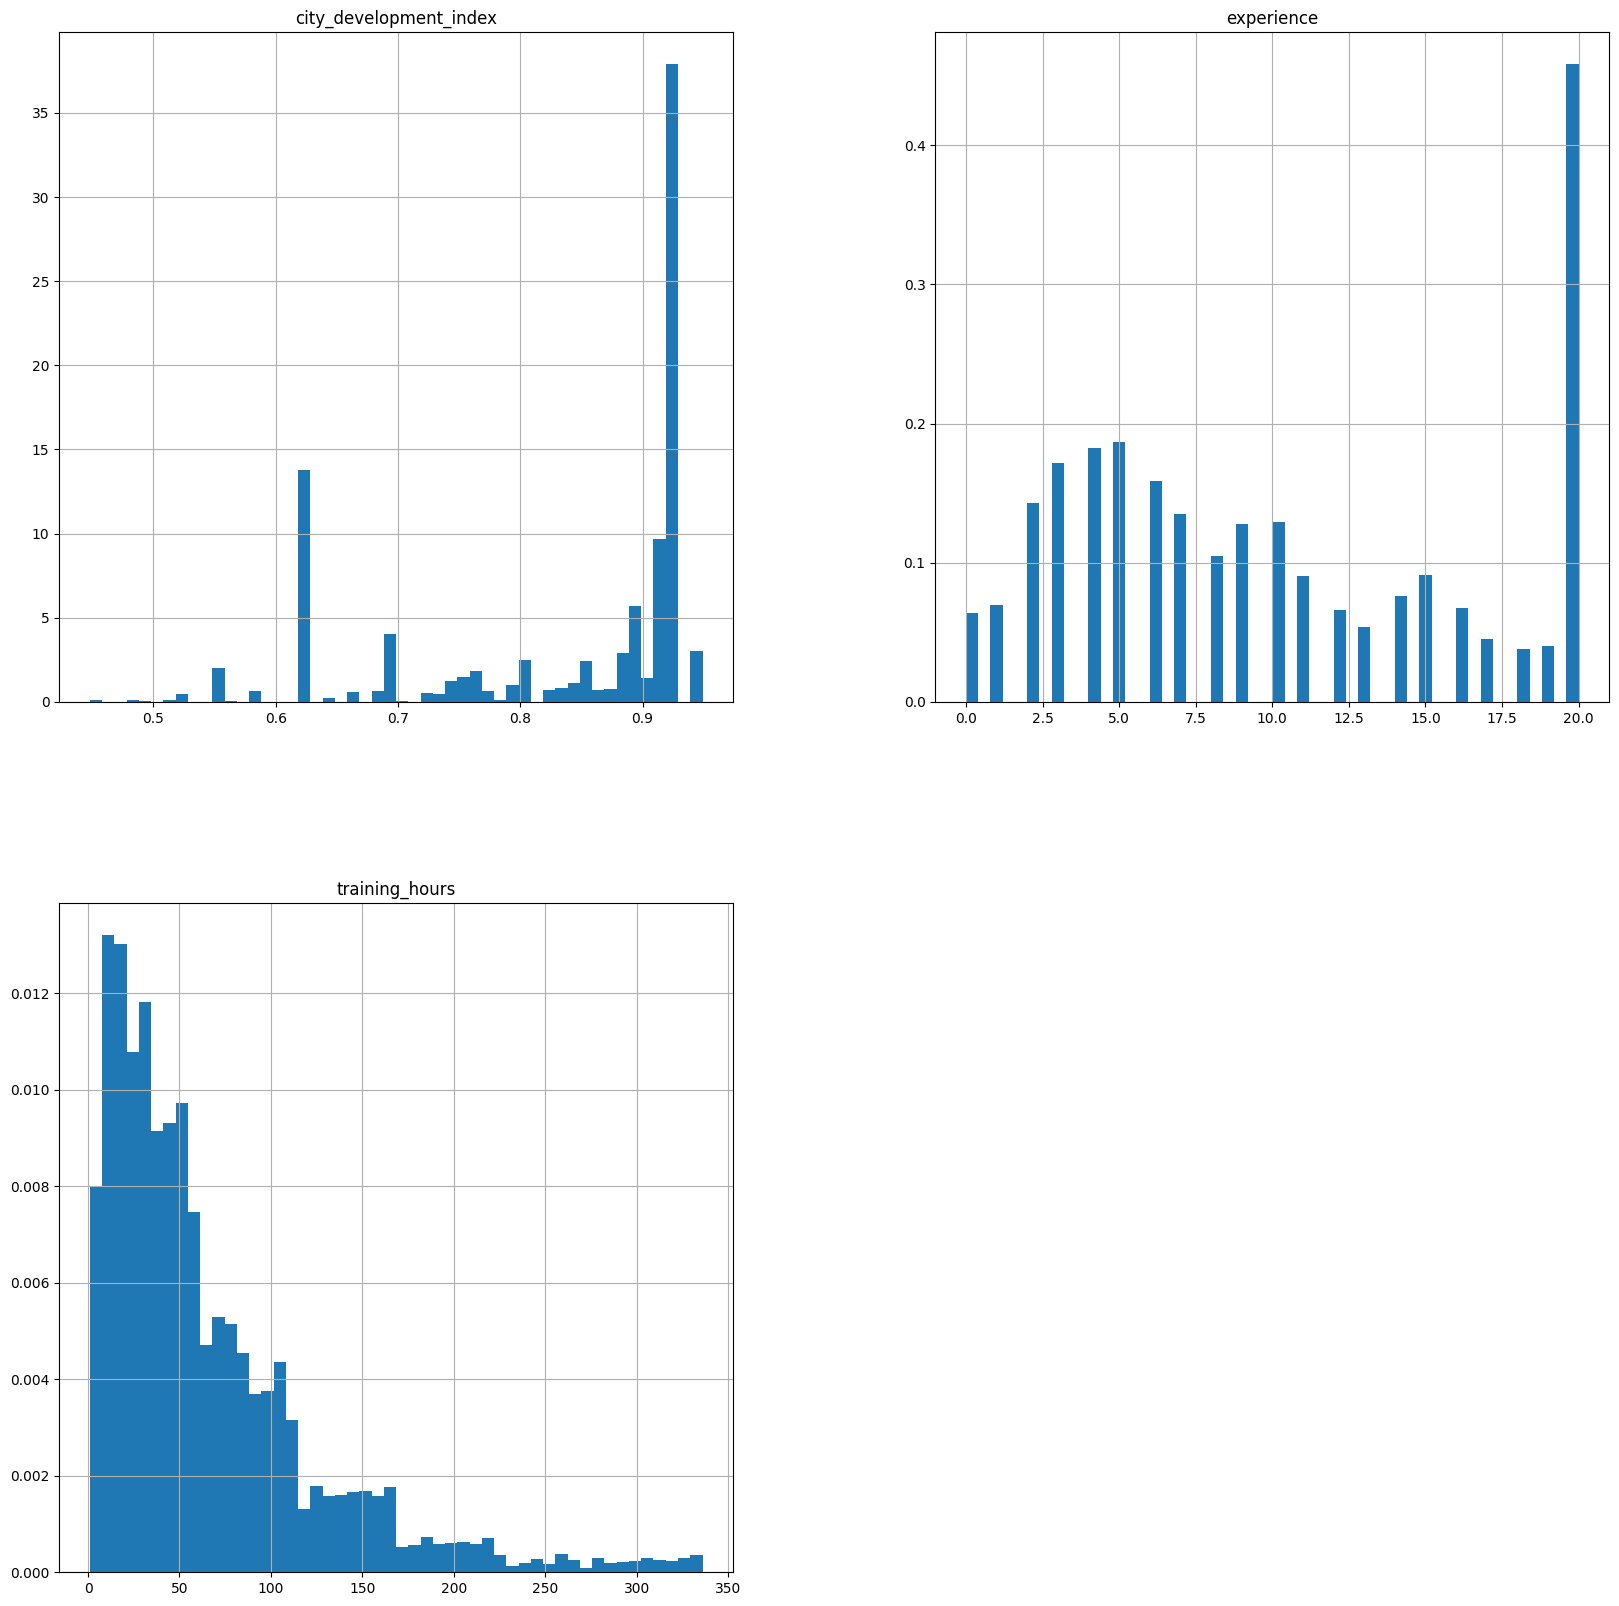

In [34]:
new_df.hist(bins=50, density = True, figsize=(20,20))

<Axes: >

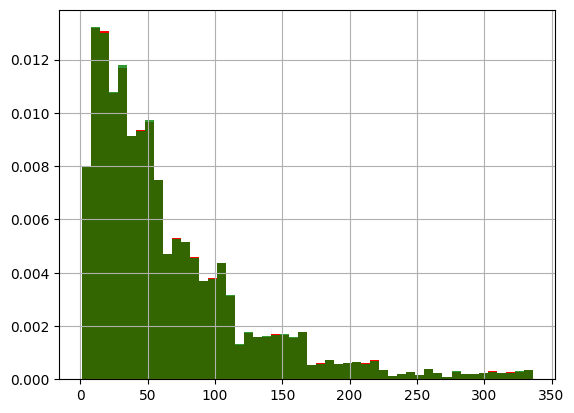

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)


#original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

#data after cca, the argument aplha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)


<Axes: ylabel='Density'>

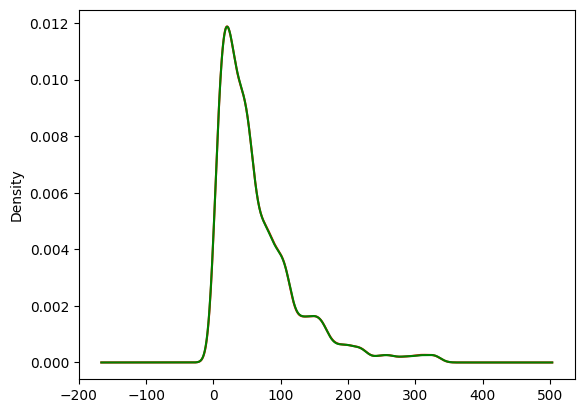

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['training_hours'].plot.density(color='red')

#data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

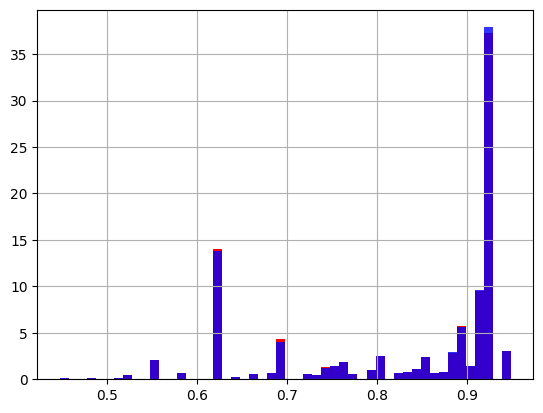

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)


#original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

#data after cca, the argument aplha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='blue', alpha=0.8)


<Axes: ylabel='Density'>

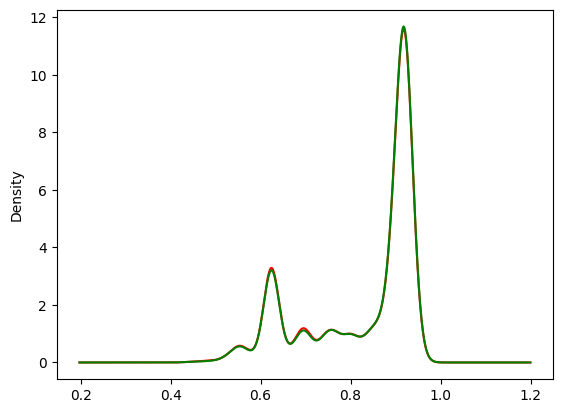

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['city_development_index'].plot.density(color='red')

#data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

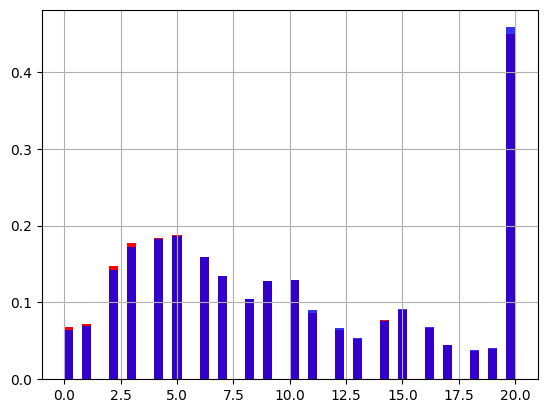

In [39]:
fig = plt.figure()
ax = fig.add_subplot(111)


#original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

#data after cca, the argument aplha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, density=True, color='blue', alpha=0.8)


<Axes: ylabel='Density'>

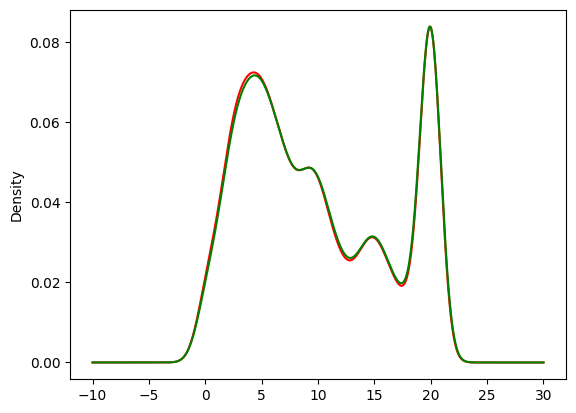

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['experience'].plot.density(color='red')

#data after cca
new_df['experience'].plot.density(color='green')

In [41]:
temp = pd.concat([df['enrolled_university'].value_counts()/len(df),
                  new_df['enrolled_university'].value_counts()/len(new_df)], axis=1)
#add column names
temp.columns = ['Original', 'cca']
temp


,Original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [42]:
temp = pd.concat([df['education_level'].value_counts()/len(df),
                  new_df['education_level'].value_counts()/len(new_df)], axis=1)
#add column names
temp.columns = ['Original', 'cca']
temp

,Original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
